# Climate Data Exploratory Data Analysis

## Introduction
This notebook contains an exploratory data analysis of climate data from 1900 to 2023. The dataset includes global temperatures, CO2 concentration, sea level rise, and Arctic ice area.

Your task is to perform a comprehensive EDA following the requirements in the README.md file.

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling
#print(plt.style.available) // to find the available of index like Solarize_Light2', '_classic_test_patch'.
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
%matplotlib inline

## 1. Data Preparation

Load the climate data and perform necessary cleaning and aggregation.

In [6]:
# Load the dataset
df = pd.read_csv("data/Climate_Change_Indicators.csv") # Place the correct path to the file you are reading here (Make sure to load using the relative path)

# Display the first few rows of the dataset
df.head()

,Year,Global Average Temperature (°C),CO2 Concentration (ppm),Sea Level Rise (mm),Arctic Ice Area (million km²)
0,1948,13.17,397.04,116.25,5.97
1,1996,13.10,313.17,277.92,9.66
2,2015,14.67,311.95,290.32,8.40
3,1966,14.79,304.25,189.71,11.83
4,1992,13.15,354.52,14.84,11.23


In [8]:
# Check for missing values and basic information about the dataset
print("Dataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048576 entries, 0 to 1048575
Data columns (total 5 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Year                             1048576 non-null  int64  
 1   Global Average Temperature (°C)  1048576 non-null  float64
 2   CO2 Concentration (ppm)          1048576 non-null  float64
 3   Sea Level Rise (mm)              1048576 non-null  float64
 4   Arctic Ice Area (million km²)    1048576 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 40.0 MB
None

Missing Values:
Year                               0
Global Average Temperature (°C)    0
CO2 Concentration (ppm)            0
Sea Level Rise (mm)                0
Arctic Ice Area (million km²)      0
dtype: int64


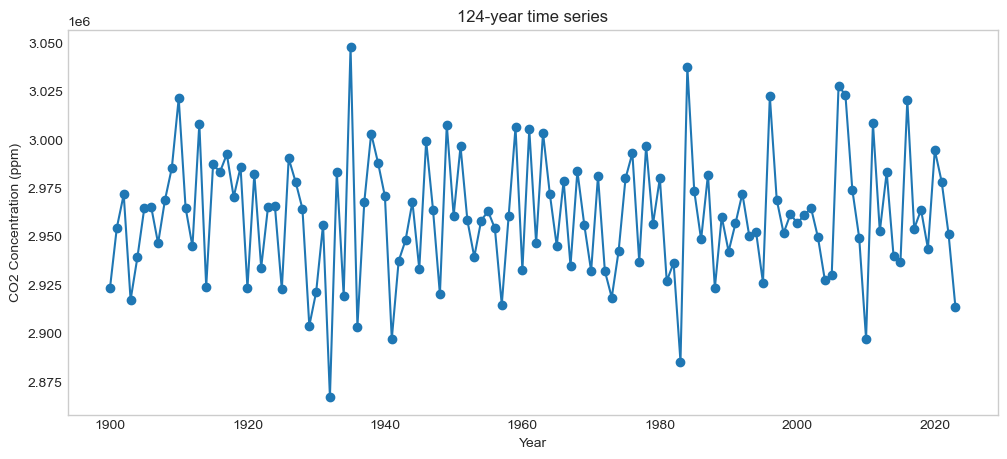

In [4]:
# TODO: Aggregate data by year to create a 124-year time series
# aggregate data by year 
#df_yearly = df.groupby('Year').agg({'value_column':'sum'}).reset_index()
df_yearly = df.groupby('Year').agg({
    'CO2 Concentration (ppm)': 'sum',  # Aggregation method sum
    'Global Average Temperature (°C)': 'sum',
    'Sea Level Rise (mm)': 'sum',
    'Arctic Ice Area (million km²)': 'sum'
}).reset_index()

plt.figure(figsize=(12,5))
plt.plot(df_yearly['Year'],df_yearly['CO2 Concentration (ppm)'], marker='o', linestyle= '-' ,color = 'tab:blue')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)' )
plt.title('124-year time series')
plt.grid()
plt.show()



## 2. Univariate Analysis

Analyze each climate variable independently.

In [ ]:
# TODO: Perform univariate analysis for each climate variable
# Include descriptive statistics and appropriate visualizations
df.head()
def univerant_analysis(df , column):
    print(f'\nDiscriptive Statistic{column}:\n', df[column].describe())
 #histrogram   
    plt.figure(figsize=(12,5)) 
    plt.subplot(1,2,1)
    sns.histplot(df[column], bins= 10 ,kde=True ,color= 'blue') 
    plt.title(f"Histogram of {column}")
    plt.show()
  #box plot
    plt.subplot(1,2,2)
    sns.boxplot(y=df[column] , color='red')
    plt.title(f"BOX PLOT of {column}")
    plt.show()


for column in df.columns[1:]:
   univerant_analysis(df,column )
   



## 3. Bivariate Analysis

Explore relationships between pairs of climate variables.

                                     Year  Global Average Temperature (°C)  \
Year                             1.000000                        -0.000500   
Global Average Temperature (°C) -0.000500                         1.000000   
CO2 Concentration (ppm)          0.000945                        -0.001417   
Sea Level Rise (mm)             -0.000969                        -0.000013   
Arctic Ice Area (million km²)   -0.000881                         0.000702   

                                 CO2 Concentration (ppm)  Sea Level Rise (mm)  \
Year                                            0.000945            -0.000969   
Global Average Temperature (°C)                -0.001417            -0.000013   
CO2 Concentration (ppm)                         1.000000             0.000206   
Sea Level Rise (mm)                             0.000206             1.000000   
Arctic Ice Area (million km²)                  -0.000541             0.000825   

                                 Arctic Ice 

<Figure size 800x600 with 0 Axes>

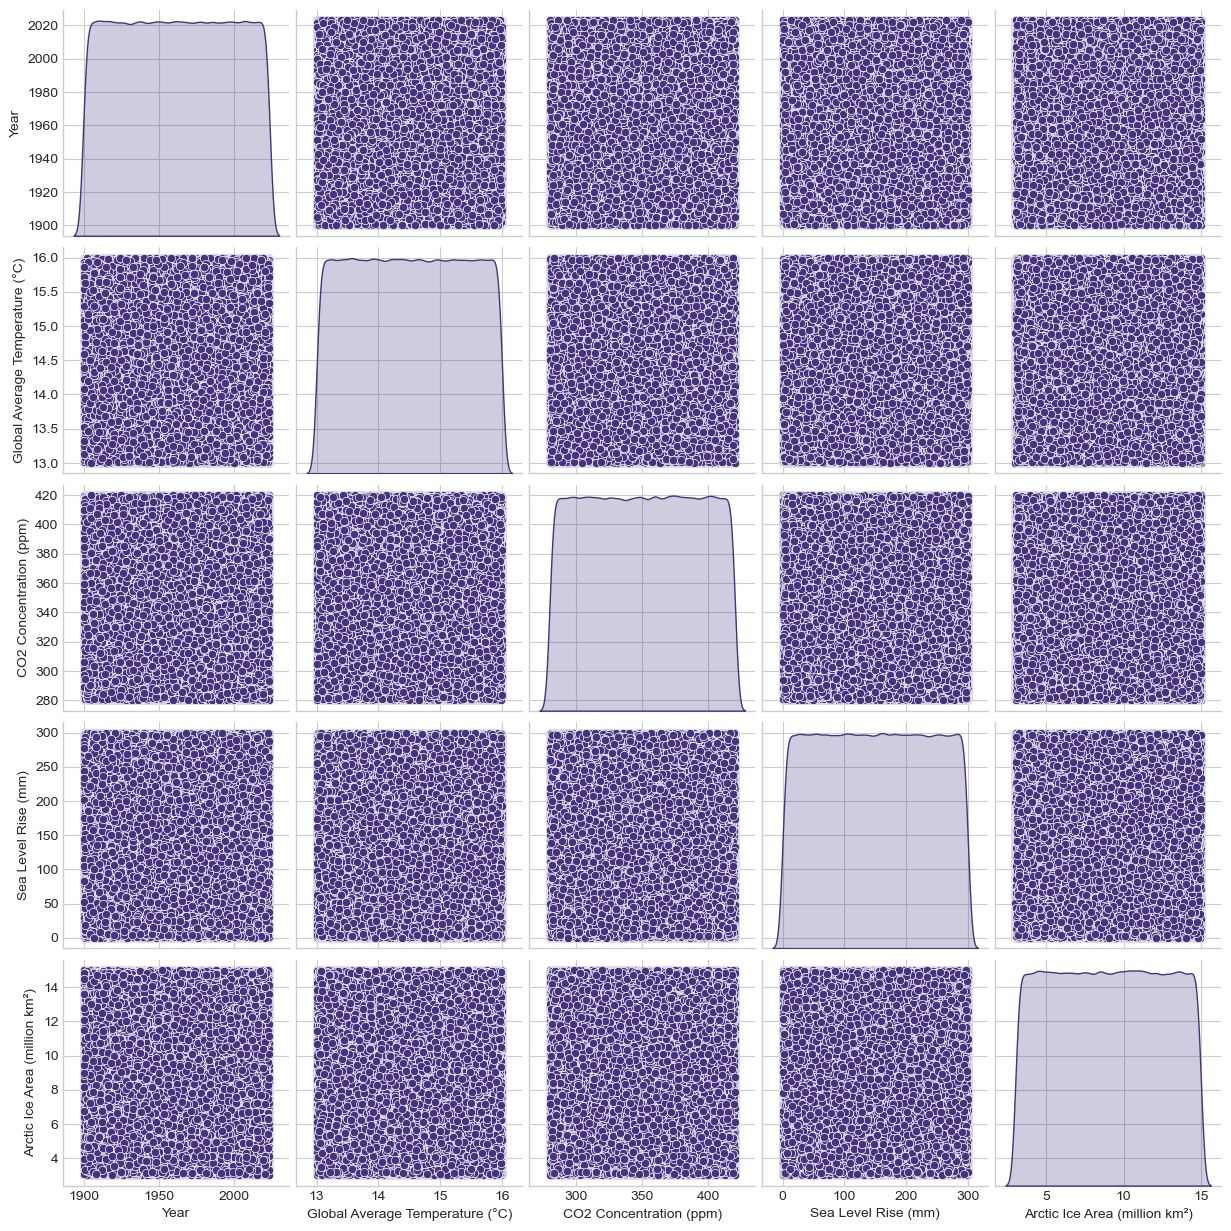

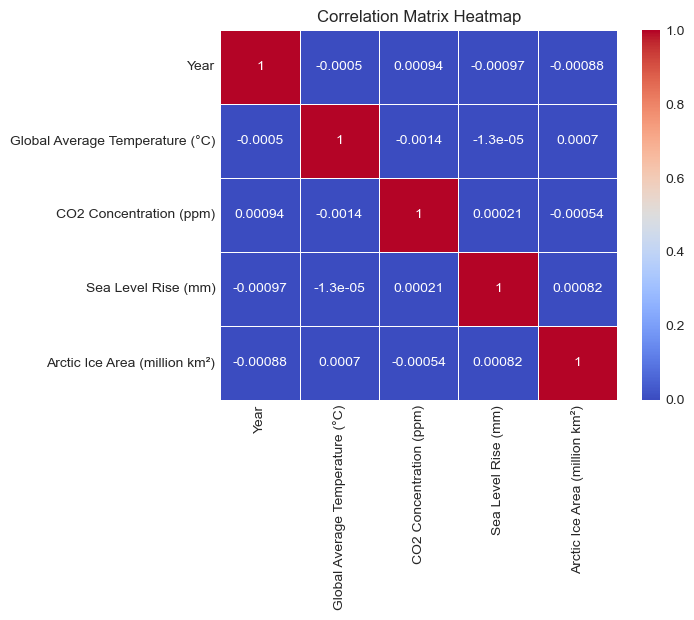

In [6]:
# TODO: Perform bivariate analysis
# Include correlation analysis and appropriate visualizations
#correlation analysis 
df.head()

def bivariate_analysis(df):
    correlatin_analysis = df.corr()
    print(correlatin_analysis)
#scatterplot 
    plt.figure(figsize= (8,6))
    sns.pairplot( df , diag_kind= 'kde', markers= 'o')
    plt.show()

#headtmap 
    sns.heatmap(correlatin_analysis,annot= True ,cmap= 'coolwarm',linewidths=0.5)
    plt.title('Correlation Matrix Heatmap')
    plt.show()
    

bivariate_analysis(df)
    





## 4. Multivariate Analysis

Investigate relationships among three or more variables.

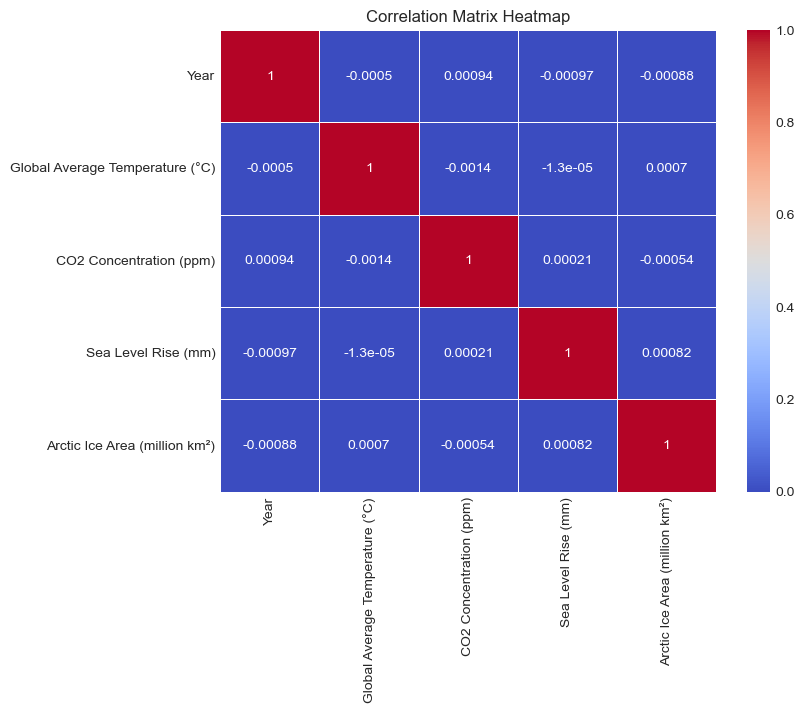

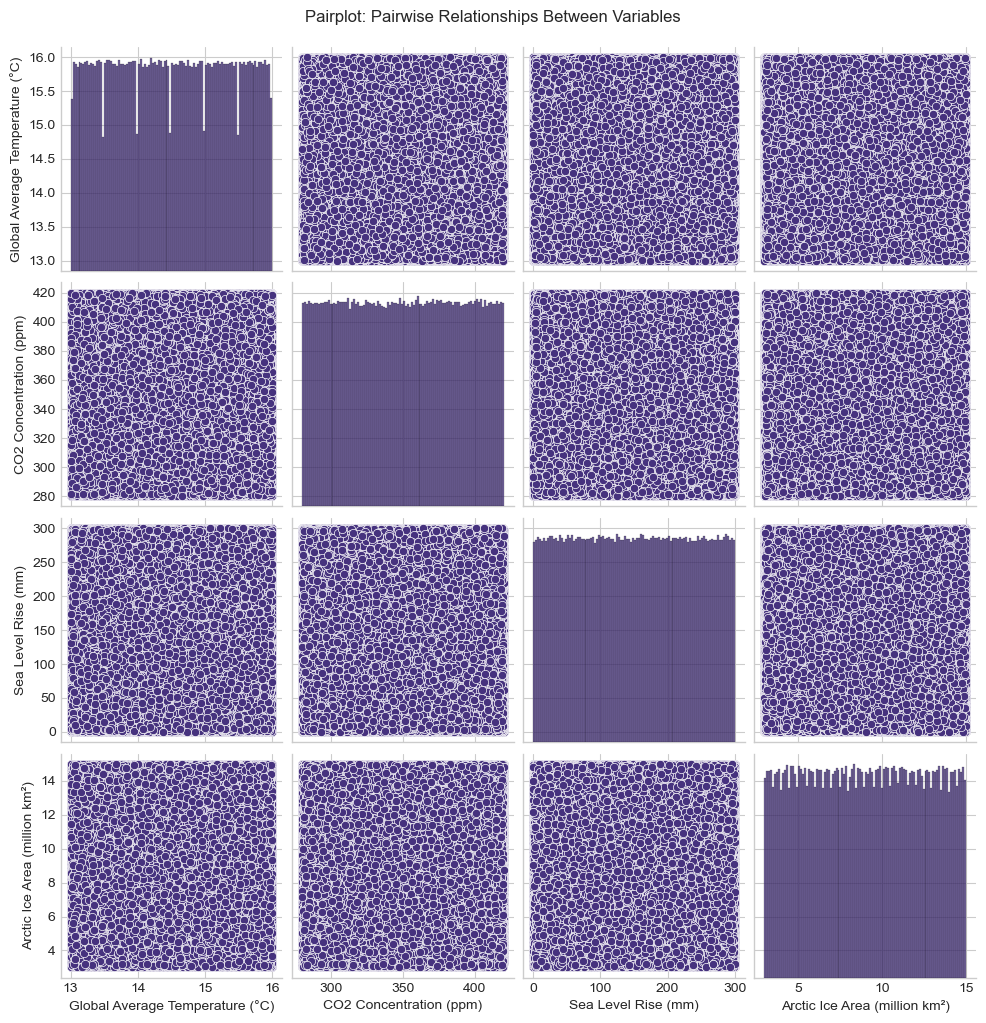

In [75]:
# TODO: Perform multivariate analysis
# Create advanced visualizations showing multiple variables
#df.head()

correlation_matrix = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")
plt.show()
#  Pairplot (Visualizing Pairwise Relationships)
sns.pairplot(df[['Global Average Temperature (°C)', 'CO2 Concentration (ppm)', 'Sea Level Rise (mm)', 'Arctic Ice Area (million km²)']])
plt.suptitle("Pairplot: Pairwise Relationships Between Variables", y=1.02)
plt.show()




## 5. Conclusions and Insights

Summarize your findings and discuss their implications.

Univariate analysis is the simplest form of statistical analysis, involving the examination of one variable at a time.
Bivariate analysis focuses on the relationship between two variables. It's commonly used to understand how one variable affects or is related to another
Multivariate analysis refers to statistical techniques used to analyze data involving more than one variable at the same time.